In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np

In [3]:
# from imblearn.over_sampling import RandomOverSampler
# from imblearn.under_sampling import RandomUnderSampler
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline  import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score,f1_score,confusion_matrix,accuracy_score,recall_score,precision_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import auc
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report
warnings.filterwarnings("ignore", category=ConvergenceWarning)



#### Loading data

In [4]:
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Create a DataFrame for visualization
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y


#### Elbow method for finding best k in Kmeans

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

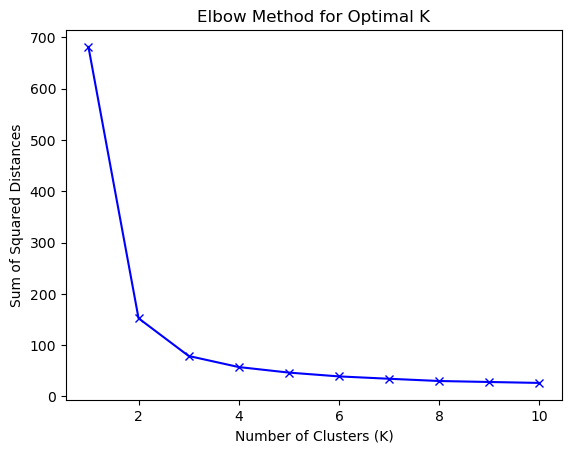

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply KMeans with a range of cluster numbers
k_values = range(1, 11)
sum_of_squared_distances = []
for k in k_values:
    kmeans = KMeans(n_clusters=k,n_init=10)
    kmeans.fit(X)
    sum_of_squared_distances.append(kmeans.inertia_)

# Plot the sum of squared distances
plt.plot(k_values, sum_of_squared_distances, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method for Optimal K')
plt.show()


#### Kmeans clustering with Principal Component Analysis

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


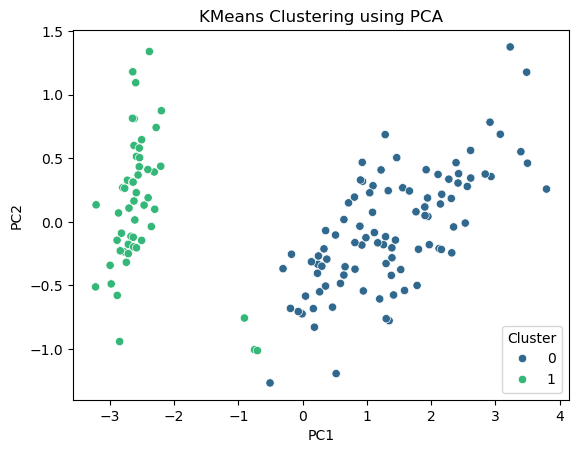

In [6]:
# Apply KMeans clustering with the optimal K
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
cluster_labels = kmeans.labels_

# Visualize the clusters using PCA
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_labels

sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis')
plt.title('KMeans Clustering using PCA')
plt.show()


#### Classification

In [7]:
import pandas as pd

# Load the German Credit dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = ["existing_account", "duration_month", "credit_history", "purpose", "credit_amount", 
           "savings_account", "employment_since", "installment_rate", "personal_status", "other_debtors", 
           "residence_since", "property", "age", "other_installment_plans", "housing", "existing_credits", 
           "job", "people_liable", "telephone", "foreign_worker", "credit_risk"]
data = pd.read_csv(url, delimiter=' ', header=None, names=columns)

# Display basic information about the dataset
print(data.head())


  existing_account  duration_month credit_history purpose  credit_amount  \
0              A11               6            A34     A43           1169   
1              A12              48            A32     A43           5951   
2              A14              12            A34     A46           2096   
3              A11              42            A32     A42           7882   
4              A11              24            A33     A40           4870   

  savings_account employment_since  installment_rate personal_status  \
0             A65              A75                 4             A93   
1             A61              A73                 2             A92   
2             A61              A74                 2             A93   
3             A61              A74                 2             A93   
4             A61              A73                 3             A93   

  other_debtors  ...  property age  other_installment_plans housing  \
0          A101  ...      A121  67     

#### Data Preprocessing

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Separate features and target variable
X = data.drop(columns=['credit_risk'])
y = data['credit_risk']

# Encode categorical variables
label_encoders = {}
for column in X.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    X[column] = label_encoders[column].fit_transform(X[column])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#### classification using logistic regression

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Train a logistic regression model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr.predict(X_test)

# Calculate accuracy
accuracy_lr = lr.score(X_test, y_test)
print("Logistic Regression Accuracy:", accuracy_lr)

# Evaluate the model
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.78
              precision    recall  f1-score   support

           1       0.81      0.90      0.85       141
           2       0.67      0.49      0.57        59

    accuracy                           0.78       200
   macro avg       0.74      0.70      0.71       200
weighted avg       0.77      0.78      0.77       200



#### Classification using Random Forest Classifier

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Train a random forest classifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

# Evaluate the model
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.785
              precision    recall  f1-score   support

           1       0.81      0.91      0.86       141
           2       0.70      0.47      0.57        59

    accuracy                           0.79       200
   macro avg       0.75      0.69      0.71       200
weighted avg       0.77      0.79      0.77       200



#### Resampling class imabance using SMOTE

In [11]:
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE



# Assuming X and y are your features and target variable respectively

# Apply SMOTE on the entire dataset
smote = SMOTE(sampling_strategy=0.9)  # Increase the sampling strategy
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Train a random forest model on the balanced data
rf_smote = RandomForestClassifier(n_estimators=100)  # Specify the number of trees
rf_smote.fit(X_train, y_train)

# Make predictions
y_pred_smote = rf_smote.predict(X_test)

# Calculate accuracy
accuracy_smote = rf_smote.score(X_test, y_test)
print("Random Forest with SMOTE Accuracy:", accuracy_smote)

# Evaluate the model
print(classification_report(y_test, y_pred_smote))


Random Forest with SMOTE Accuracy: 0.8082706766917294
              precision    recall  f1-score   support

           1       0.81      0.83      0.82       141
           2       0.80      0.78      0.79       125

    accuracy                           0.81       266
   macro avg       0.81      0.81      0.81       266
weighted avg       0.81      0.81      0.81       266

